In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from scipy.ndimage import gaussian_filter
import os
from triangular_transport.flows.methods.sampling import inf_train_gen

plt.style.use("ggplot")

In [2]:
no_trials = 10

def load_ode_mean(base_dir, result_dir, no_trials):
    """Load ODE convergence runs and return the trial-averaged W2 error."""
    run_base = os.path.join(base_dir, result_dir)
    arr = None
    for i in range(no_trials):
        data = np.load(os.path.join(run_base, f"run_{i:02d}", f"nn_conv_wd_{i}.npy"))
        if arr is None:
            arr = np.zeros((no_trials, len(data)))
        arr[i, :] = data
    return np.mean(arr, axis=0)

# ---- Banana (paths relative to banana/ where this notebook lives) ----
# green=y=-4.2, pink=y=-1, black=y=0
snl_b        = np.load("sample_no_list.npy").tolist()
ode_b_green  = load_ode_mean(".", "converge_results_4",      no_trials)
ode_b_pink   = load_ode_mean(".", "converge_results_banana", no_trials)
ode_b_black  = load_ode_mean(".", "converge_results_0",      no_trials)
mcmc_b_green  = np.load("mcmc_results_4/avg_wd_mcmc.npy")
mcmc_b_pink   = np.load("mcmc_results_1/avg_wd_mcmc.npy")
mcmc_b_black  = np.load("mcmc_results_0/avg_wd_mcmc.npy")

# ---- 8 Gaussians ----
# green=y=-2.95, pink=y=0, black=y=2.45
gd           = "../8gaussians"
snl_g        = np.load(os.path.join(gd, "sample_no_list.npy")).tolist()
ode_g_green  = load_ode_mean(gd, "converge_results_3", no_trials)
ode_g_pink   = load_ode_mean(gd, "converge_results_0", no_trials)
ode_g_black  = load_ode_mean(gd, "converge_results_2", no_trials)
mcmc_g_green  = np.load(os.path.join(gd, "mcmc_results_3/avg_wd_mcmc.npy"))
mcmc_g_pink   = np.load(os.path.join(gd, "mcmc_results_0/avg_wd_mcmc.npy"))
mcmc_g_black  = np.load(os.path.join(gd, "mcmc_results_2/avg_wd_mcmc.npy"))

# ---- Tanh ----
# green=y=-3, pink=y=0, black=y=2
td           = "../tanh"
snl_t        = np.load(os.path.join(td, "sample_no_list.npy")).tolist()
ode_t_green  = load_ode_mean(td, "converge_results_3", no_trials)
ode_t_pink   = load_ode_mean(td, "converge_results_0", no_trials)
ode_t_black  = load_ode_mean(td, "converge_results_2", no_trials)
mcmc_t_green  = np.load(os.path.join(td, "mcmc_results_3/avg_wd_mcmc.npy"))
mcmc_t_pink   = np.load(os.path.join(td, "mcmc_results_0/avg_wd_mcmc.npy"))
mcmc_t_black  = np.load(os.path.join(td, "mcmc_results_2/avg_wd_mcmc.npy"))

In [3]:
banana_samps = inf_train_gen(data="banana",     batch_size=100000)
gauss_samps  = inf_train_gen(data="8gaussians", batch_size=100000)

rng = np.random.RandomState(42)
yst = rng.uniform(low=-3.0, high=3.0, size=(50000, 1))
ust = np.tanh(yst) + rng.gamma(shape=1.0, scale=0.3, size=(50000, 1))
tanh_samps = np.hstack([yst, ust])

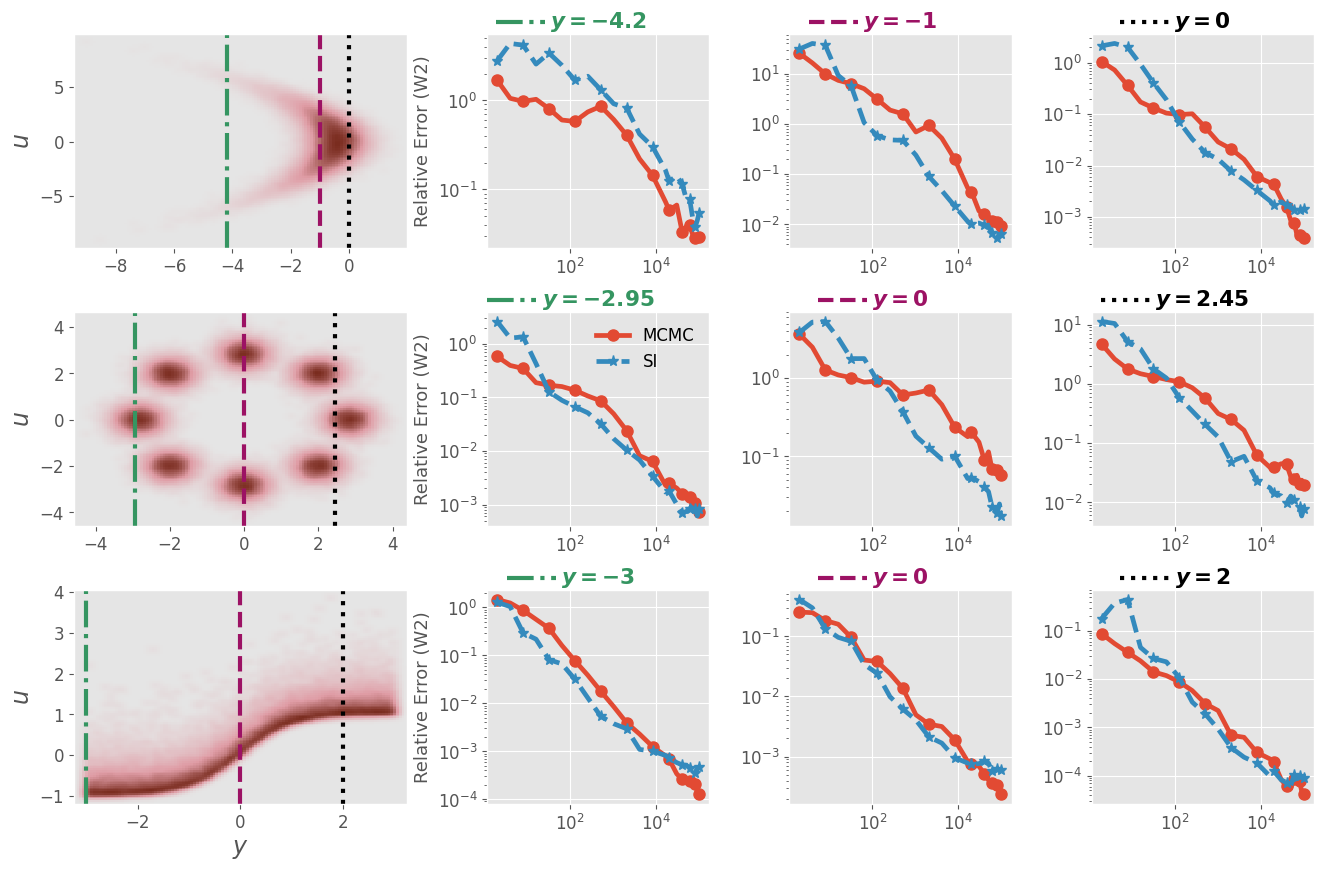

In [4]:
GREEN   = "#359561"
PINK    = "#9c1264"
BLACK   = "#000000"
SCATTER = "#df9ca5"

DENSITY_CMAP = LinearSegmentedColormap.from_list(
    "density_rose", ["#e5e5e5", SCATTER, "#7a2c1f"]
)

LINESTYLE_FOR_COLOR = {GREEN: "dashdot", PINK: "--", BLACK: "dotted"}

plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

def plot_density(ax, xs, ys, bins=120, pad_frac=0.04, sigma=1.2):
    """Smoothed 2D histogram (Gaussian-blurred, rendered with pcolormesh) so the
    joint distribution reads as a continuous heatmap rather than a blurred scatter.
    Padding + locked axis limits keep conditioning lines near the data edges from
    getting clipped by axvline."""
    xmin, xmax = xs.min(), xs.max()
    ymin, ymax = ys.min(), ys.max()
    xpad = pad_frac * (xmax - xmin)
    ypad = pad_frac * (ymax - ymin)
    xrange = (xmin - xpad, xmax + xpad)
    yrange = (ymin - ypad, ymax + ypad)
    hist, xedges, yedges = np.histogram2d(xs, ys, bins=bins, range=[xrange, yrange])
    hist = gaussian_filter(hist, sigma=sigma)
    ax.pcolormesh(xedges, yedges, hist.T, cmap=DENSITY_CMAP, norm=PowerNorm(0.5),
                  shading="auto", rasterized=True)
    ax.set_xlim(xrange)
    ax.set_ylim(yrange)
    ax.set_autoscale_on(False)

def plot_conv(ax, snl, mcmc, ode, title_color, title_str,
              add_legend=False, add_ylabel=False):
    ax.plot(snl, mcmc, marker="o", markevery=2, linewidth=3.4, markersize=8, label="MCMC")
    ax.plot(snl, ode,  marker="*", linestyle="dashed", linewidth=3.4, markersize=8,
            markevery=2, label="SI")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(rf"$\boldsymbol{{y = {title_str}}}$", fontsize=15.6, pad=2, color=title_color)
    if add_legend:
        ax.legend(loc="upper right", fontsize=12, frameon=False)
    if add_ylabel:
        ax.set_ylabel("Relative Error (W2)", fontsize=13)

def add_title_swatch(ax, renderer, gap=0.025, length=0.22, lw=3):
    """Draw a small line-style/color swatch immediately to the left of ax's title,
    matching the corresponding conditioning line drawn in the sample-scatter column.
    length is long enough for dashdot/dashed to show a full repeat of their pattern."""
    color = ax.title.get_color()
    linestyle = LINESTYLE_FOR_COLOR.get(color)
    if linestyle is None:
        return
    bbox = ax.title.get_window_extent(renderer=renderer)
    inv = ax.transAxes.inverted()
    (x0, y0), (x1, y1) = inv.transform([(bbox.x0, bbox.y0), (bbox.x1, bbox.y1)])
    y_mid = (y0 + y1) / 2
    ax.plot([x0 - gap - length, x0 - gap], [y_mid, y_mid], transform=ax.transAxes,
            linestyle=linestyle, color=color, linewidth=lw, clip_on=False,
            solid_capstyle="butt")

fig, axes = plt.subplots(
    3, 4, figsize=(16, 10),
    gridspec_kw={"width_ratios": [1.5, 1, 1, 1]}
)
plt.subplots_adjust(hspace=0.3, wspace=0.32)

# ======== Row 0: Banana ========
ax = axes[0, 0]
plot_density(ax, banana_samps[:, 0], banana_samps[:, 1])
ax.axvline(x=-4.2, linestyle="dashdot", linewidth=3, c=GREEN)
ax.axvline(x=-1.0, linestyle="--",      linewidth=3, c=PINK)
ax.axvline(x= 0.0, linestyle="dotted",  linewidth=3, c=BLACK)
ax.set_ylabel(r"$u$", fontsize=17)

plot_conv(axes[0,1], snl_b, mcmc_b_green, ode_b_green, GREEN, "-4.2",
          add_legend=False, add_ylabel=True)
plot_conv(axes[0,2], snl_b, mcmc_b_pink,  ode_b_pink,  PINK,  "-1")
plot_conv(axes[0,3], snl_b, mcmc_b_black, ode_b_black, BLACK, "0")

# ======== Row 1: 8 Gaussians ========
ax = axes[1, 0]
plot_density(ax, gauss_samps[:, 0], gauss_samps[:, 1])
ax.axvline(x=-2.95, linestyle="dashdot", linewidth=3, c=GREEN)
ax.axvline(x= 0.0,  linestyle="--",      linewidth=3, c=PINK)
ax.axvline(x= 2.45, linestyle="dotted",  linewidth=3, c=BLACK)
ax.set_ylabel(r"$u$", fontsize=17)

plot_conv(axes[1,1], snl_g, mcmc_g_green, ode_g_green, GREEN, "-2.95", add_legend=True,
          add_ylabel=True)
plot_conv(axes[1,2], snl_g, mcmc_g_pink,  ode_g_pink,  PINK,  "0")
plot_conv(axes[1,3], snl_g, mcmc_g_black, ode_g_black, BLACK, "2.45")

# ======== Row 2: Tanh ========
ax = axes[2, 0]
plot_density(ax, tanh_samps[:, 0], tanh_samps[:, 1])
ax.axvline(x=-3.0, linestyle="dashdot", linewidth=3, c=GREEN)
ax.axvline(x= 0.0, linestyle="--",      linewidth=3, c=PINK)
ax.axvline(x= 2.0, linestyle="dotted",  linewidth=3, c=BLACK)
ax.set_ylabel(r"$u$", fontsize=17)
ax.set_xlabel(r"$y$", fontsize=17)

plot_conv(axes[2,1], snl_t, mcmc_t_green, ode_t_green, GREEN, "-3",
          add_ylabel=True)
plot_conv(axes[2,2], snl_t, mcmc_t_pink,  ode_t_pink,  PINK,  "0")
plot_conv(axes[2,3], snl_t, mcmc_t_black, ode_t_black, BLACK, "2")

fig.canvas.draw()
renderer = fig.canvas.get_renderer()
for row in range(3):
    for col in (1, 2, 3):
        add_title_swatch(axes[row, col], renderer)

os.makedirs("images", exist_ok=True)
plt.savefig("images/combined_joint_conv.png", dpi=300, bbox_inches="tight")
plt.show()